In [2]:
from statistics import quantiles

#Zadanie 1
import pandas as pd
import numpy as np
df = pd.read_csv('Otodom_Flat_Listings.csv')
completeness = (1 - df.isnull().mean()) * 100
valid_price = (df['Price'] > 0).mean() * 100
dq_metric = (completeness.mean() + valid_price) / 2
print("KOmpletność cech [%]: ", completeness)
print(f"Procent rekordów z poprawną ceną (>0): {valid_price:.2f}%")
print(F"Zbiorcza metryka jakości danych: {dq_metric:.2f}%")

KOmpletność cech [%]:  Title                     100.000000
Price                      94.905593
Location                   99.964375
Surface                   100.000000
Number_of_Rooms           100.000000
Floor                      97.719986
Finishing_Condition        79.408621
Heating                    73.387959
Parking_Space              52.654079
Balcony_Garden_Terrace     74.884218
Link                      100.000000
Voivodeship                99.964375
City                       99.964375
dtype: float64
Procent rekordów z poprawną ceną (>0): 94.91%
Zbiorcza metryka jakości danych: 92.56%


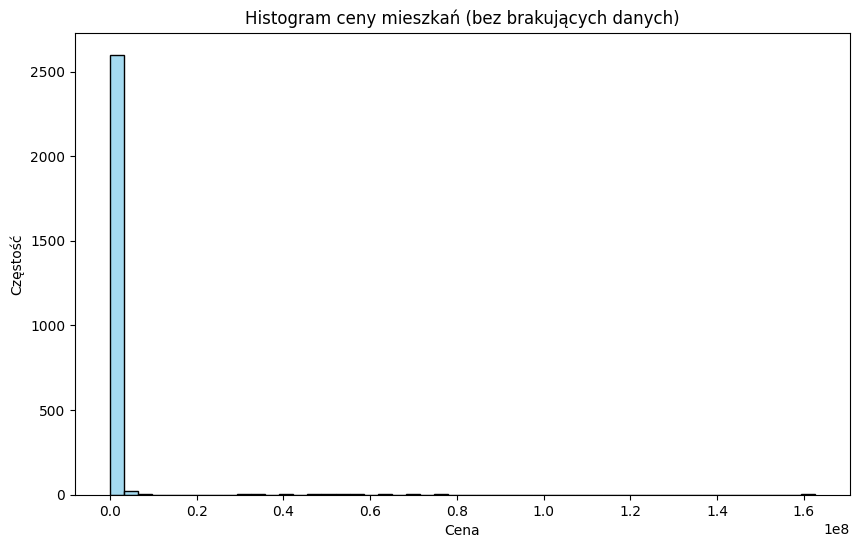

In [3]:
#Zadanie 2
import matplotlib.pyplot as plt
import seaborn as sns
df_clean_price = df.dropna(subset=['Price'])
plt.figure(figsize=(10, 6))
sns.histplot(df_clean_price['Price'], bins=50, kde=False, color='skyblue')
plt.title('Histogram ceny mieszkań (bez brakujących danych)')
plt.xlabel('Cena')
plt.ylabel('Częstość')
plt.show()

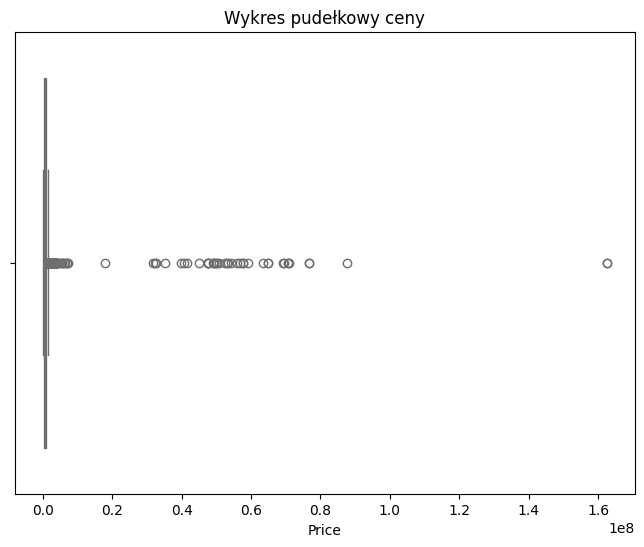

Liczba zidentyfikowanych wartości odstających: 200


In [5]:
#Zadanie 3
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_clean_price['Price'], color = 'lightcoral')
plt.title('Wykres pudełkowy ceny')
plt.show()

Q1 = df_clean_price['Price'].quantile(0.25)
Q3 = df_clean_price['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_data = df_clean_price[(df_clean_price['Price'] < lower_bound) | (df_clean_price['Price'] > upper_bound)]
print(f"Liczba zidentyfikowanych wartości odstających: {len(outlier_data)}")

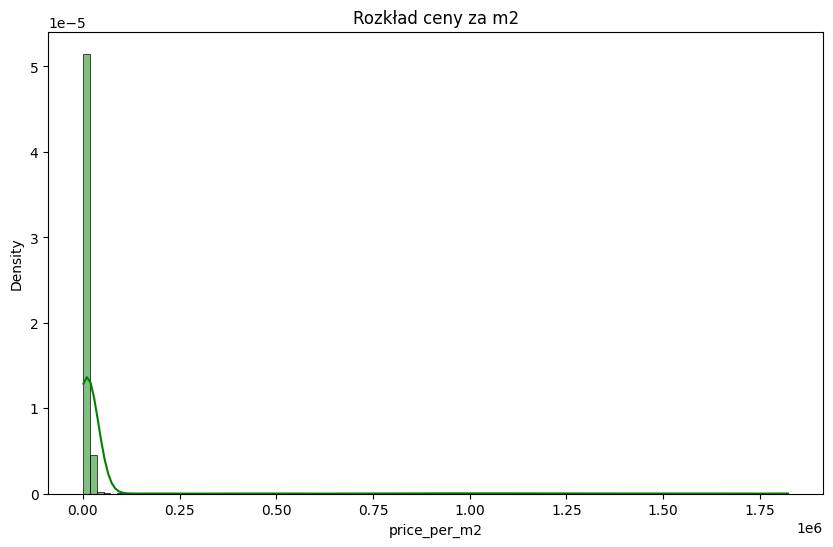

Kwartyle dla price_per_m2:  0.25     7583.333333
0.50    10354.037664
0.75    13922.705452
Name: price_per_m2, dtype: float64


In [8]:
#Zadanie 4
from scipy.stats import norm
df['price_per_m2'] = df['Price'] / df['Surface']
data_m2 = df['price_per_m2'].dropna()
data_m2 = data_m2[np.isfinite(data_m2)]
plt.figure(figsize=(10, 6))
sns.histplot(data_m2, kde=True, stat="density", color='green')
plt.title('Rozkład ceny za m2')
plt.show()
quartiles = data_m2.quantile([0.25, 0.5, 0.75])
print("Kwartyle dla price_per_m2: ", quartiles)

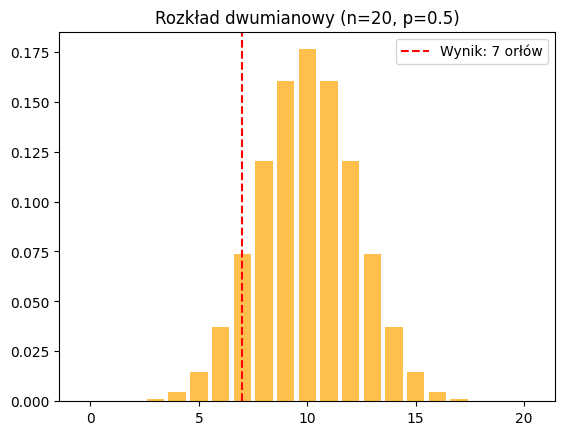

Teoretyczne prawdopodobieństwo wypadnięcia dokładnie 7 orłów: 0.0739


In [9]:
#Zadanie 5
from scipy.stats import binom
n = 20
k = 7
p = 0.5
prob_7 = binom.pmf(k, n, p)
x = np.arange(0, 21)
plt.bar(x, binom.pmf(x, n, p), color='orange', alpha=0.7)
plt.axvline(k, color='red', linestyle='--', label=f'Wynik: {k} orłów')
plt.title(f'Rozkład dwumianowy (n=20, p=0.5)')
plt.legend()
plt.show()
print(f"Teoretyczne prawdopodobieństwo wypadnięcia dokładnie 7 orłów: {prob_7:.4f}")

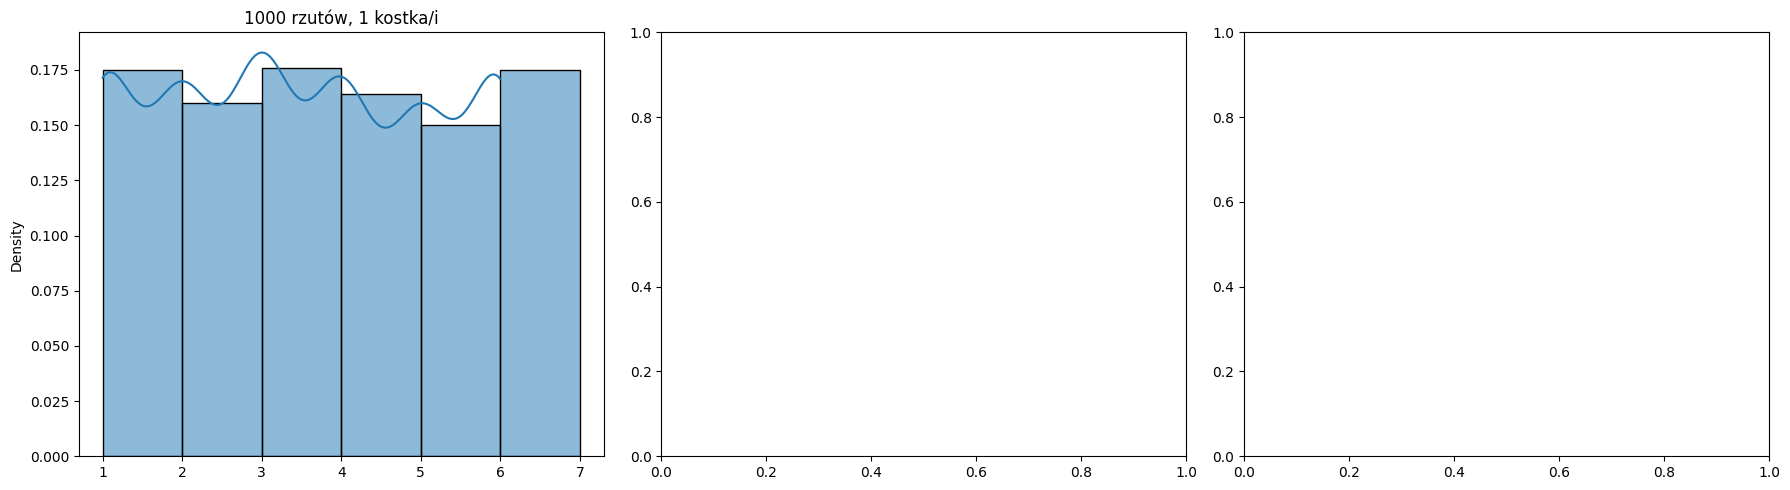

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [10]:
#Zadanie 6
import random
def symulacja_kostek(liczba_eksperymentow, liczba_kostek=1):
    wyniki=[]
    for _ in range(liczba_eksperymentow):
        suma_oczek = sum(random.randint(1, 6) for _ in range(liczba_kostek))
        wyniki.append(suma_oczek)
    return wyniki

parametry = [(1000, 1), (1000, 2), (1000, 5)]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (eksperymenty, kostki) in enumerate(parametry):
    dane = symulacja_kostek(eksperymenty, kostki)
    sns.histplot(dane, kde=True, ax=axes[i], bins=range(kostki, 6*kostki + 2), stat="density")
    axes[i].set_title(f'{eksperymenty} rzutów, {kostki} kostka/i')
    plt.tight_layout()
    plt.show()